## Missing Values'
- MCAR -> missing value completely at random -> NO pattern -> Safe to drop or impute
- MAR -> Missing at Random
- MNAR -> Missing Not at Random

In [52]:
import seaborn as sns
import pandas as pd
import numpy as np

df = sns.load_dataset("titanic")
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [53]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


### Method 1 : Dropping Missing Values
- Very Few Missing Values
- column is not important
- dataloss is acceptable
- Last Option

In [54]:
df.dropna()  #drop rows

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [55]:
df.dropna(axis=1) #drop columns

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


###  Imputation -> It means replacing missing values with estimated values

### Numerical Features -->
- Mean Imputation -> When data follows approximately Normal Distribution

<Axes: xlabel='age', ylabel='Count'>

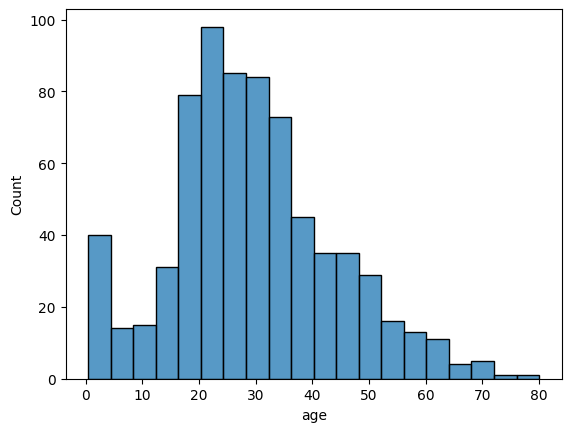

In [56]:
sns.histplot(x=df['age'])

In [57]:
df['Age'] = df['age'].fillna(df['age'].mean())

#Median Imputation ---> Used when data contains Outliers.

In [58]:
df['Age'] = df['age'].fillna(df['age'].median())
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,22.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,38.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,26.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,35.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,35.0


In [59]:
#Categorical Features

#Mode Imputation --> Most frequent values

In [60]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
Age              0
dtype: int64

In [61]:
df['embarked'].mode()[0]

'S'

In [62]:
df['Embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

### Group Based Imputation -> Instead of using the overall mean, we can calculate means within groupp

In [63]:
df.groupby('sex')['age'].mean()

sex
female    27.915709
male      30.726645
Name: age, dtype: float64

#### Guide
- <5% or less then delete or simple imputation
-  5% - 30% then statistical imputation
-  more than 30% Drop Feature or advanced imputation

#### Forward fill ffill

In [64]:
df = pd.DataFrame({
    'Temperature' : [30,np.nan,32,np.nan,35,36]
})

In [65]:
forward_filled = df.ffill()
forward_filled

,Temperature
0,30.0
1,30.0
2,32.0
3,32.0
4,35.0
5,36.0


In [66]:
backward_filled = df.bfill()
backward_filled

,Temperature
0,30.0
1,32.0
2,32.0
3,35.0
4,35.0
5,36.0


In [67]:
#Missing Indicator Engineering

df = pd.DataFrame({
    'Income':[10000,20000,np.nan,90000,np.nan]
})

In [68]:
df['Income_missing']=df['Income'].isnull().astype('int')#this give boolean
df

,Income,Income_missing
0,10000.0,0
1,20000.0,0
2,NaN,1
3,90000.0,0
4,NaN,1


### Categorical Data and Data Encoding

In [69]:
df = pd.DataFrame({
    'City' : ['Ktm','Pkr','Butwal','Chitwan'],
    'Category' : ['A','B','C','A']
})

In [70]:
df

,City,Category
0,Ktm,A
1,Pkr,B
2,Butwal,C
3,Chitwan,A


In [71]:
#Label Encoding --> Simple , Use only one column , Good for Binary Categories
#Model may incorrectly assume : Tech > HR > Finance

from sklearn.preprocessing import LabelEncoder

df = pd.DataFrame({
    'Department':['HR','Finance','Tech','HR']

})

encoder = LabelEncoder()
df['Department_Encoded'] = encoder.fit_transform(df['Department'])
df

,Department,Department_Encoded
0,HR,1
1,Finance,0
2,Tech,2
3,HR,1


In [72]:
#One - Hot Encoding --> Creates a separate Binary colums for each category

df = pd.DataFrame({
    'Fuel_type' : ['Petrol','Diesel','EV','Petrol']

})
df

,Fuel_type
0,Petrol
1,Diesel
2,EV
3,Petrol


In [73]:
encoded = pd.get_dummies(df,columns=['Fuel_type']).astype(int)
encoded


#ADV - NO False Ordering , Most commonly used encoding , Nominal Categories
#DISADV - If a clumns contains hundred of categories, OHE may create too many Columns
#Curse of Dimensionality

,Fuel_type_Diesel,Fuel_type_EV,Fuel_type_Petrol
0,0,0,1
1,1,0,0
2,0,1,0
3,0,0,1


In [74]:
#Ordinal Encoding --> Used when Categories have natural order.
df= pd.DataFrame({
    'Education': ['School','Graduate','Post-Graduate','Graduate']
})
df

,Education
0,School
1,Graduate
2,Post-Graduate
3,Graduate


In [75]:
order = {
    'School':1,
    'Graduate':2,
    'Post-Graduate':3
         }
df["Education_encoded"] = df['Education'].map(order)
df

,Education,Education_encoded
0,School,1
1,Graduate,2
2,Post-Graduate,3
3,Graduate,2


In [76]:
#Frequency Encoding

df = pd.DataFrame({
    'Browser':['Chrome','Firefox','Chrome','Edge','Chrome']
})
df

,Browser
0,Chrome
1,Firefox
2,Chrome
3,Edge
4,Chrome


In [77]:
freq = df['Browser'].value_counts(normalize=True)
freq

Browser
Chrome     0.6
Firefox    0.2
Edge       0.2
Name: proportion, dtype: float64

In [78]:
df['Browser_freq'] = df['Browser'].map(freq)
df

,Browser,Browser_freq
0,Chrome,0.6
1,Firefox,0.2
2,Chrome,0.6
3,Edge,0.2
4,Chrome,0.6


In [79]:
#Target Encoding --> Replace Each Category with the average value of the target varible for that category.
df = pd.DataFrame({
    'Profession': ['Engineer','Teacher','Engineer','Artist'],
    'Approved' : [12,3,14,4]
})
df

,Profession,Approved
0,Engineer,12
1,Teacher,3
2,Engineer,14
3,Artist,4


In [80]:
means = df.groupby('Profession')['Approved'].mean()

df['Profession_Target_Encoded'] = (df['Profession'].map(means))
df

,Profession,Approved,Profession_Target_Encoded
0,Engineer,12,13.0
1,Teacher,3,3.0
2,Engineer,14,13.0
3,Artist,4,4.0
